In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/HaiderrX/Spotify-Streaming-Analysis/refs/heads/main/train.csv")
df.head(3)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


# Exploratory Analysis:

## Information Taken:

- 1 Missing piece of information with an unnamed artist, album, track name
- Need to convert Object type to String
- So far, dropping the 'Unnamed' column seems reasonable as it provides no purpose

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

## Missing Value:

- This seems to be an error entry as the 'duration_ms' records 0 seconds with unknown song information such as the artist's credit. The only "valuable" information is the genre but it does not add anything to keeping this token of data in the dataset.

In [ ]:
df[df.isnull().any(axis=1)]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Missing Value Dropped

In [ ]:
df = df.dropna()

### Dropped Column

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  bool   
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

In [ ]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Duplicated Values
- Kept because of 'track_genre' column

In [ ]:
#df[df.duplicated()]

## Column Conversion:
- Converted 'track_id', 'artists', 'album_name', 'track_name', 'track_genre' from type Object to String

In [ ]:
cols_to_convert = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']
df = df.astype({col: 'string' for col in cols_to_convert})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   track_id          113999 non-null  string  
 1   artists           113999 non-null  string  
 2   album_name        113999 non-null  string  
 3   track_name        113999 non-null  string  
 4   popularity        113999 non-null  int64   
 5   duration_ms       113999 non-null  int64   
 6   explicit          113999 non-null  bool    
 7   danceability      113999 non-null  float64 
 8   energy            113999 non-null  float64 
 9   key               113999 non-null  int64   
 10  loudness          113999 non-null  float64 
 11  mode              113999 non-null  int64   
 12  speechiness       113999 non-null  float64 
 13  acousticness      113999 non-null  float64 
 14  instrumentalness  113999 non-null  float64 
 15  liveness          113999 non-null  float64 
 16  valence

## Numerical Anaylsis:

### Are they Continous?

Continous Columns:
- popularity
- danceability
- energy
- key
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo

In [ ]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Text(0.5, 1.0, 'Correlation between Audio Features')

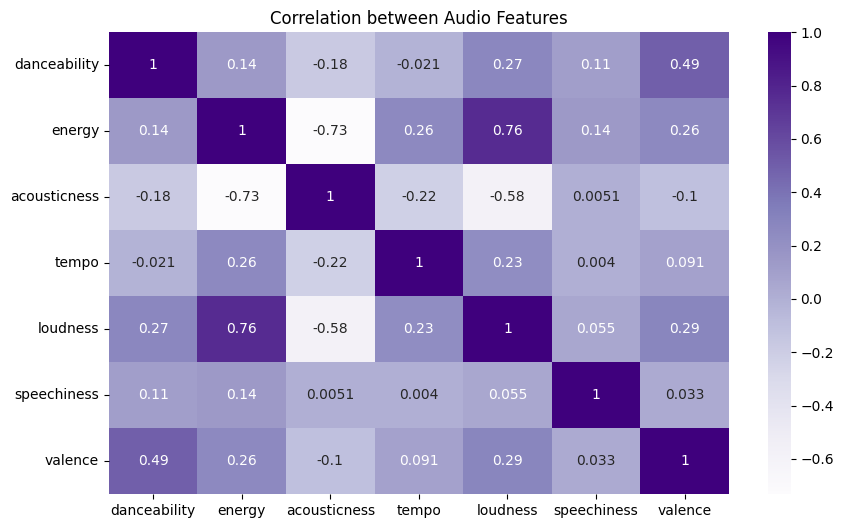

In [ ]:
continuous = ['danceability', 'energy', 'acousticness', 'tempo', 'loudness', 'speechiness', 'valence']

plt.figure(figsize=(10, 6))
sns.heatmap(df[continuous].corr(), annot=True, cmap="Purples")
plt.title("Correlation between Audio Features")

In [ ]:
#sns.pairplot(df[continuous])

## Visualization

<ipython-input-5-3c9d9a17cfe7>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_loudness = df.groupby('energy_bin')['loudness'].mean()


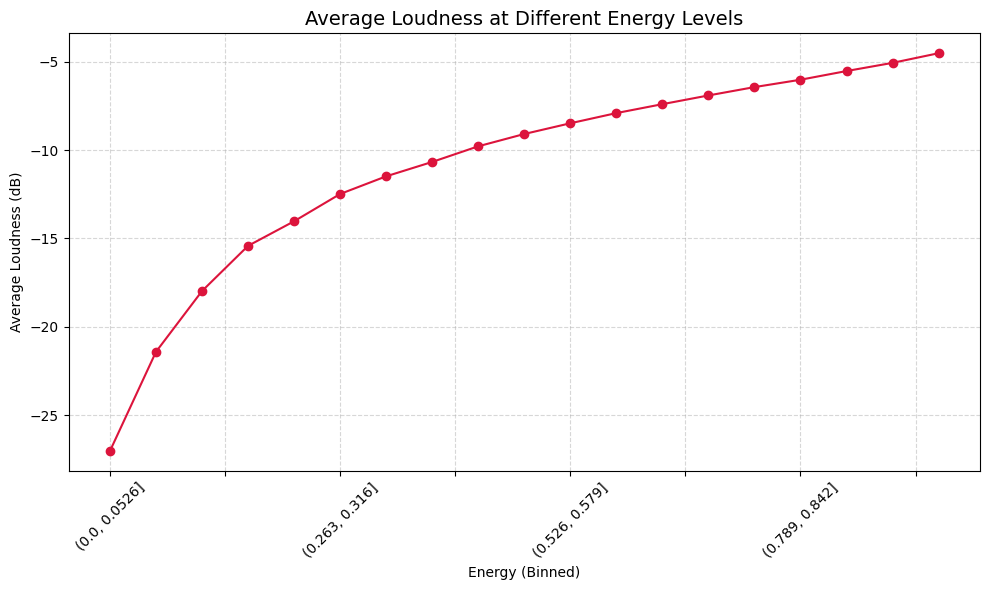

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=df['energy'], y=df['loudness'], alpha=0.4, color='crimson')
# plt.title("Distribution of Songs by Energy and Loudness", fontsize=12)
# plt.xlabel("Energy")
# plt.ylabel("Loudness (dB)")
# plt.tight_layout()

# Duplicates were dropped

# 1. Create energy bins (split energy 0–1 into 20 pieces)
df['energy_bin'] = pd.cut(df['energy'], bins=np.linspace(0, 1, 20))

# 2. Group by energy_bin and calculate average loudness
avg_loudness = df.groupby('energy_bin')['loudness'].mean()

plt.figure(figsize=(10, 6))
avg_loudness.plot(kind='line', marker='o', color='crimson')
plt.title("Average Loudness at Different Energy Levels", fontsize=14)
plt.xlabel("Energy (Binned)")
plt.ylabel("Average Loudness (dB)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<ipython-input-6-797f5fb7ccf1>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_acousticness = df.groupby('energy_bin')['acousticness'].mean()


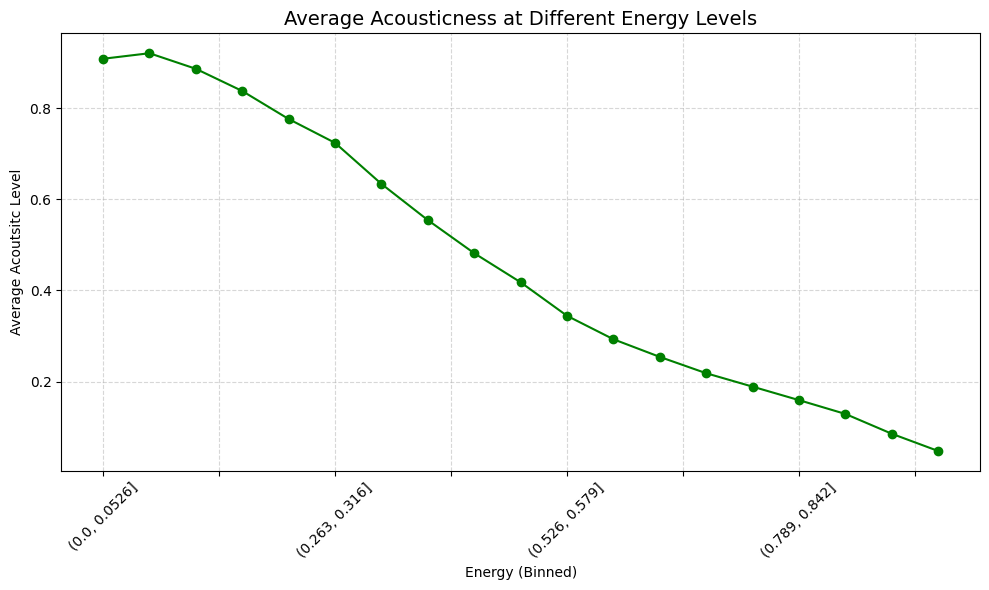

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=df['energy'], y=df['acousticness'], alpha=0.3, color='green')
# plt.title("Distribution of Songs by Energy and Acousticness", fontsize=12)
# plt.xlabel("Energy")
# plt.ylabel("Acousticness")
# plt.tight_layout()

# Duplicates were dropped

# 1. Create energy bins (split energy 0–1 into 20 pieces)
df['energy_bin'] = pd.cut(df['energy'], bins=np.linspace(0, 1, 20))

avg_acousticness = df.groupby('energy_bin')['acousticness'].mean()

plt.figure(figsize=(10, 6))
avg_acousticness.plot(kind='line', marker='o', color='green')
plt.title("Average Acousticness at Different Energy Levels", fontsize=14)
plt.xlabel("Energy (Binned)")
plt.ylabel("Average Acoutsitc Level")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<ipython-input-7-ee8d4898d44f>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_loudness_by_acousticness = df.groupby('acousticness_bin')['loudness'].mean()


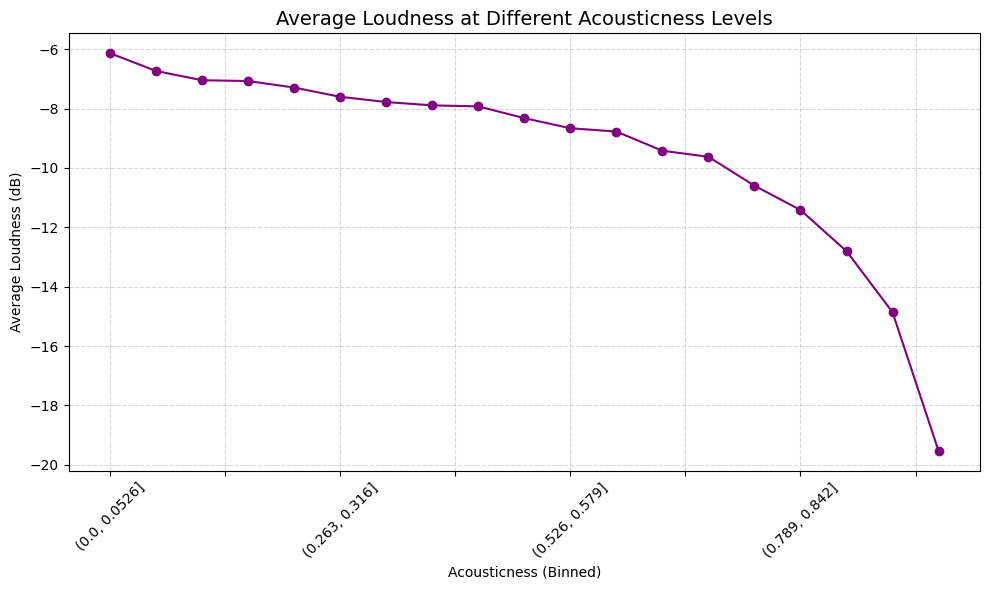

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=df['acousticness'], y=df['loudness'], alpha=0.4, color='purple')
# plt.title("Distribution of Songs by Acousticness and Loudness", fontsize=12)
# plt.xlabel("Acousticness")
# plt.ylabel("Loudness (dB)")
# plt.tight_layout()

# Duplicates were dropped

# 1. Create bins for acousticness (split from 0 to 1)
df['acousticness_bin'] = pd.cut(df['acousticness'], bins=np.linspace(0, 1, 20))

avg_loudness_by_acousticness = df.groupby('acousticness_bin')['loudness'].mean()

plt.figure(figsize=(10, 6))
avg_loudness_by_acousticness.plot(kind='line', marker='o', color='purple')
plt.title("Average Loudness at Different Acousticness Levels", fontsize=14)
plt.xlabel("Acousticness (Binned)")
plt.ylabel("Average Loudness (dB)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


<ipython-input-8-2311a82b9664>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_loudness_by_acousticness = df.groupby('valence_bin')['danceability'].mean()


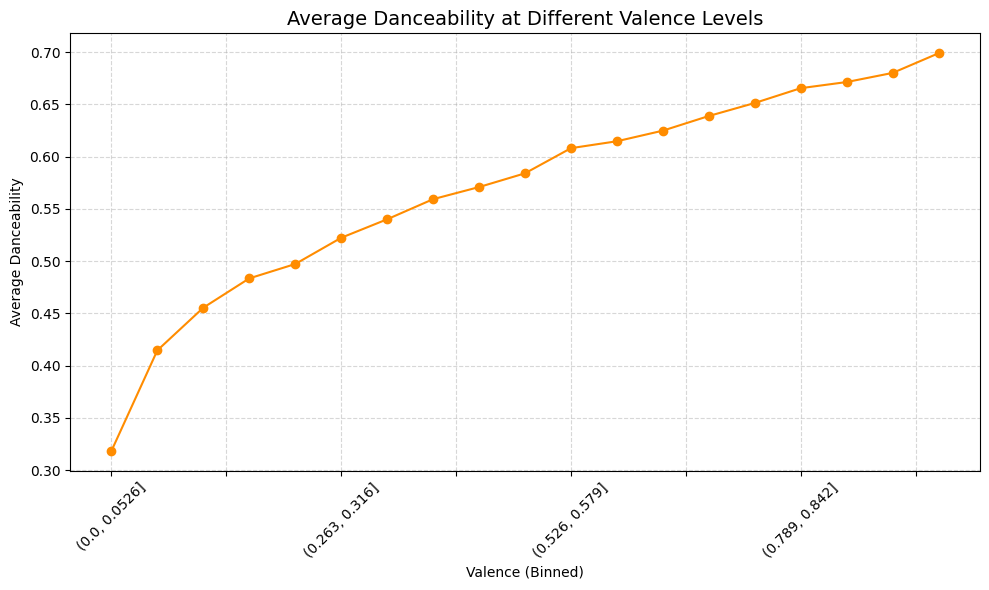

In [ ]:
# Duplicates were dropped

df['valence_bin'] = pd.cut(df['valence'], bins=np.linspace(0, 1, 20))

avg_loudness_by_acousticness = df.groupby('valence_bin')['danceability'].mean()

plt.figure(figsize=(10, 6))
avg_loudness_by_acousticness.plot(kind='line', marker='o', color='darkorange')
plt.title("Average Danceability at Different Valence Levels", fontsize=14)
plt.xlabel("Valence (Binned)")
plt.ylabel("Average Danceability")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<ipython-input-9-b84a18af05d6>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_loudness_by_acousticness = df.groupby('tempo_bin')['loudness'].mean()


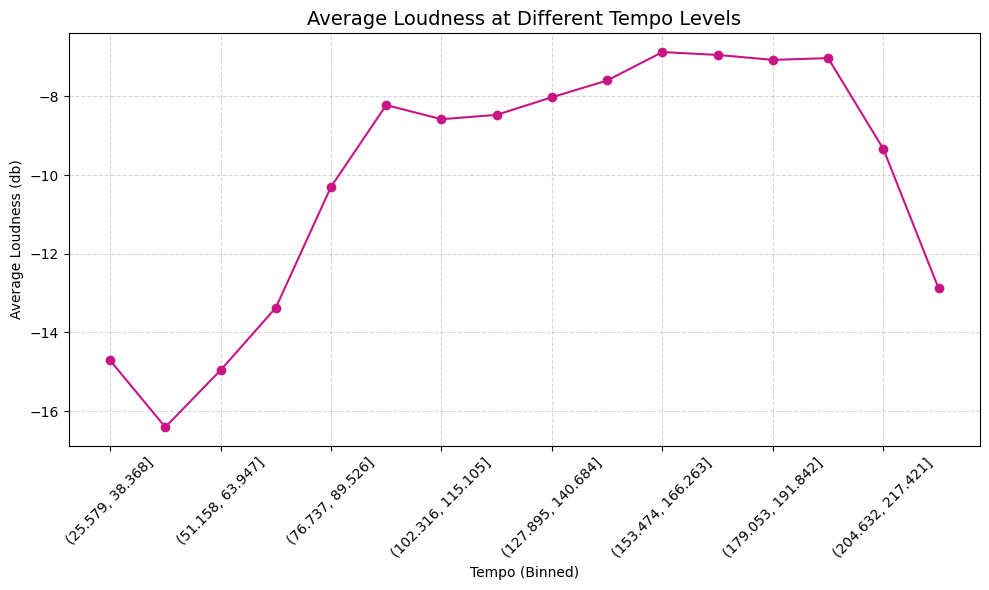

In [ ]:
# 1. Create bins for acousticness (split from 0 to 1)
# Duplicates were dropped

df['tempo_bin'] = pd.cut(df['tempo'], bins=np.linspace(0, 243, 20))

avg_loudness_by_acousticness = df.groupby('tempo_bin')['loudness'].mean()

plt.figure(figsize=(10, 6))
avg_loudness_by_acousticness.plot(kind='line', marker='o', color='mediumvioletred')
plt.title("Average Loudness at Different Tempo Levels", fontsize=14)
plt.xlabel("Tempo (Binned)")
plt.ylabel("Average Loudness (db)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

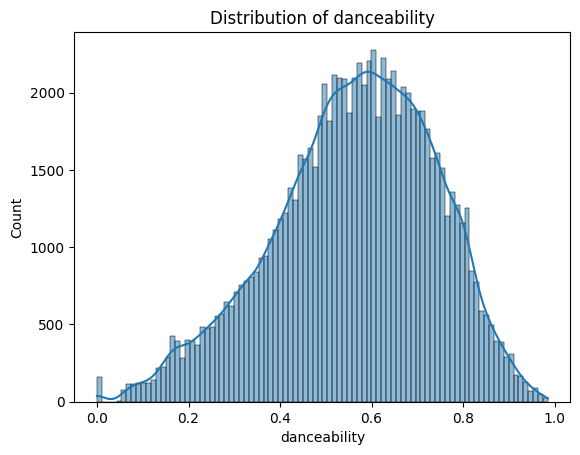

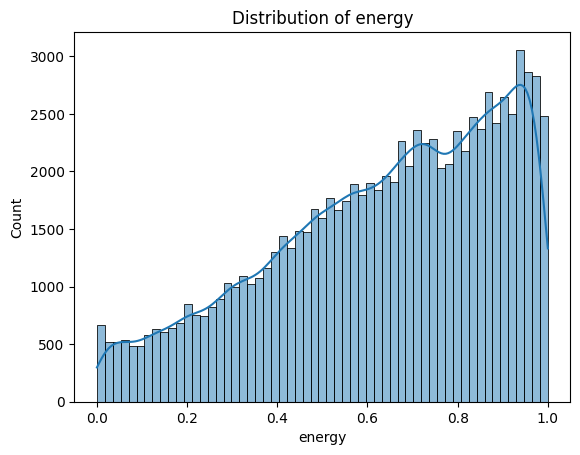

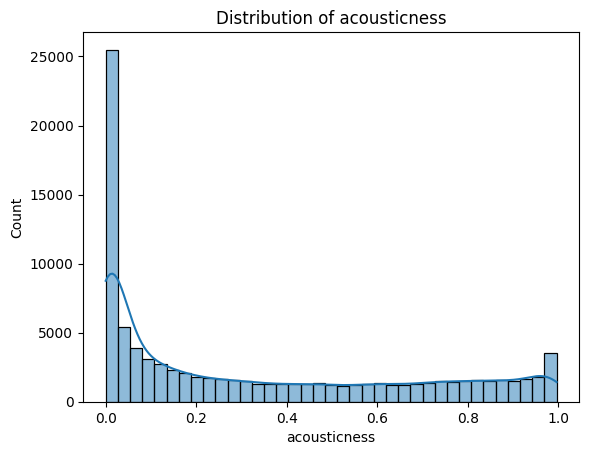

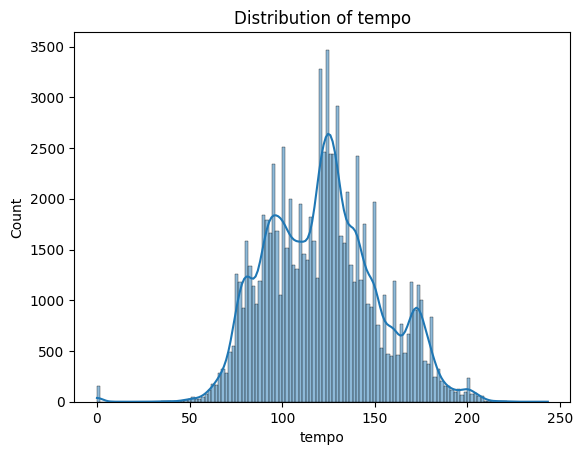

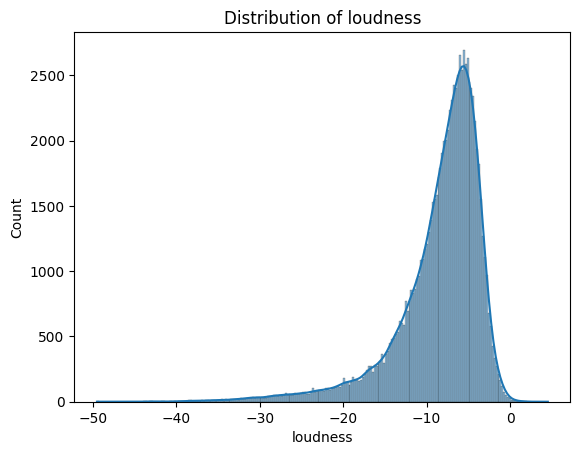

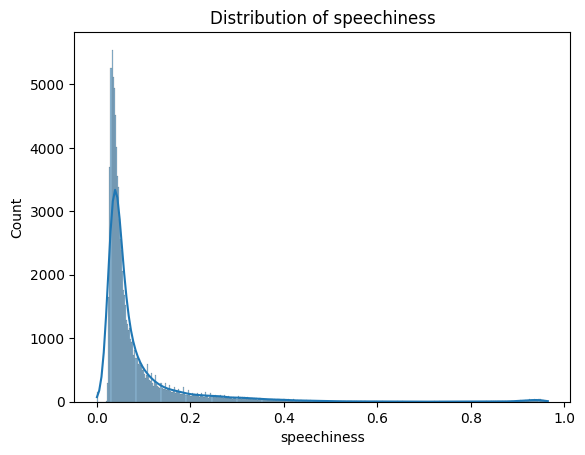

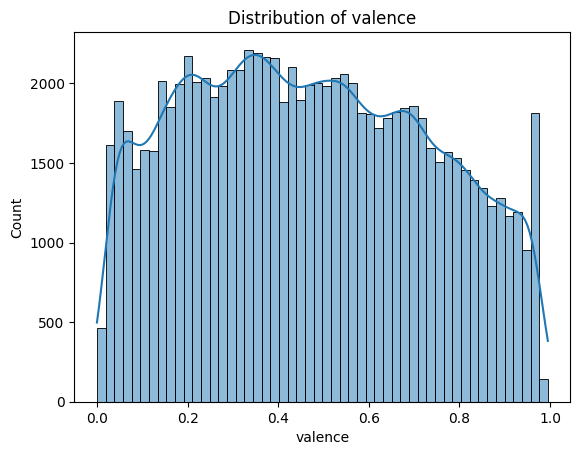

In [ ]:
for col in continuous:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Categorical Variables

In [ ]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

<Axes: title={'center': 'Top 10 Genres Occurence'}, xlabel='track_genre', ylabel='Counts'>

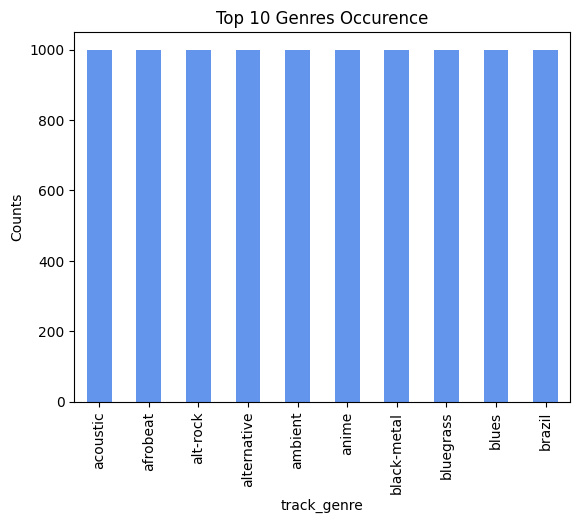

In [ ]:
# Top 10 Genres, Artsts, Albums that occurs frequently in the dataset?
plt.title("Top 10 Genres Occurence")
plt.ylabel("Counts")
df['track_genre'].value_counts().nlargest(10).plot(kind='bar', color="cornflowerblue")

<Axes: title={'center': 'Top 10 Artists Occurence'}, xlabel='artists', ylabel='Counts'>

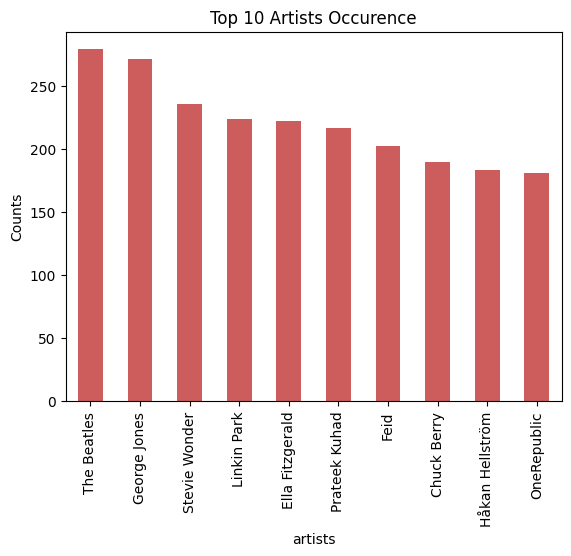

In [ ]:
plt.title("Top 10 Artists Occurence")
plt.ylabel("Counts")
df['artists'].value_counts().nlargest(10).plot(kind='bar', color='indianred')

<Axes: title={'center': 'Top 10 Albums Occurence'}, xlabel='album_name', ylabel='Counts'>

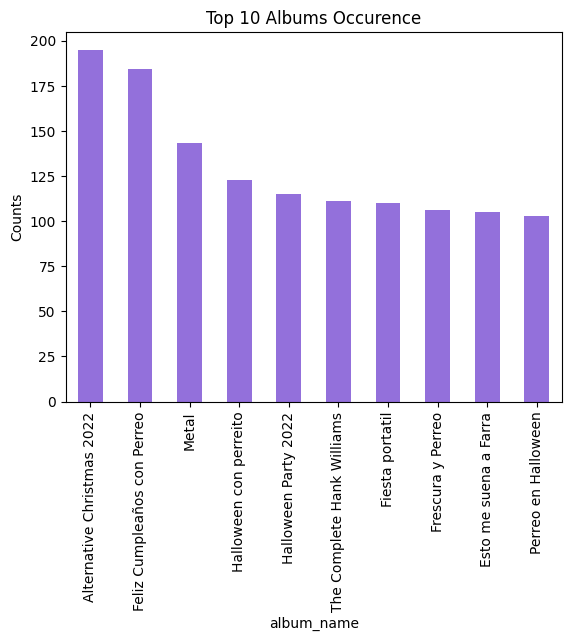

In [ ]:
plt.title("Top 10 Albums Occurence")
plt.ylabel("Counts")
df['album_name'].value_counts().nlargest(10).plot(kind='bar', color='mediumpurple')

In [ ]:
df['artists'].value_counts().nlargest(10)

,count
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
Prateek Kuhad,217
Feid,202
Chuck Berry,190
Håkan Hellström,183


Used to fill out table for unique track values in report

In [ ]:
#df[df['artists'] == "The Beatles"]['track_name'].unique()
#df[df['artists'] == "George Jones"]['track_name'].unique()
#df[df['artists'] == "Stevie Wonder"]['track_name'].unique()
#df[df['artists'] == "Linkin Park"]['track_name'].unique()
#df[df['artists'] == "Ella Fitzgerald"]['track_name'].unique()
#df[df['artists'] == "Prateek Kuhad"]['track_name'].unique()
#df[df['artists'] == "Feid"]['track_name'].unique()
#df[df['artists'] == "Chuck Berry"]['track_name'].unique()
#df[df['artists'] == "Håkan Hellström"]['track_name'].unique()
#df[df['artists'] == "OneRepublic"]['track_name'].unique()

# Higher Level Analysis

### Even when dropping duplicates, nothing seemed to change

Text(0, 0.5, '')

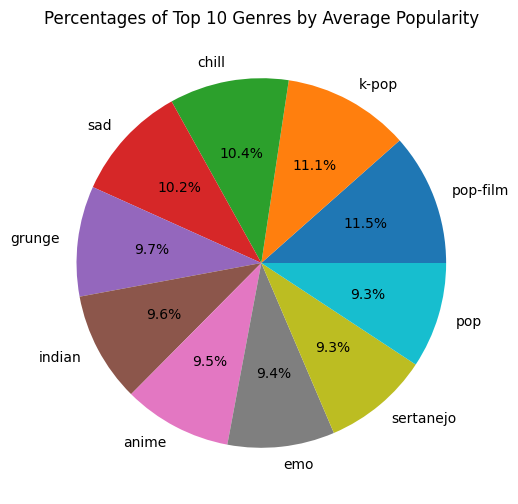

In [ ]:
# Analysis 1: Average Popular Track Genres:
plt.figure(figsize=(10,6))
df.groupby("track_genre")['popularity'].mean().nlargest(10).plot(kind='pie', autopct='%1.1f%%', title="Percentages of Top 10 Genres by Average Popularity")
plt.ylabel('')

### Dropping duplicates, no effect

Text(0, 0.5, '')

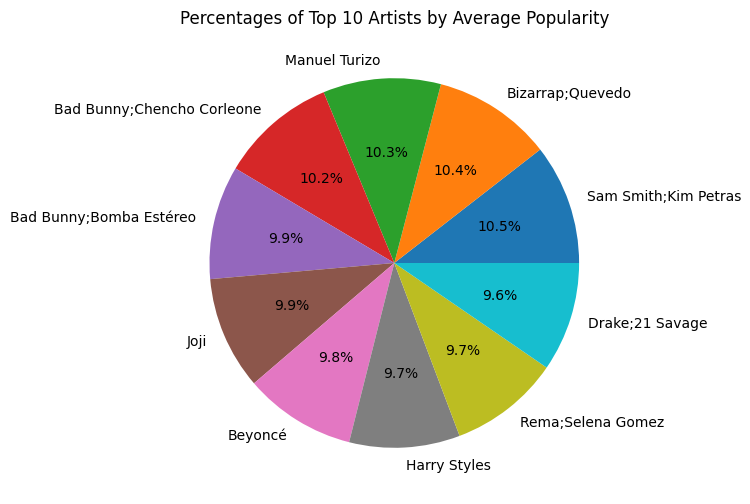

In [ ]:
# Analysis 2: Average Popular Artists:
plt.figure(figsize=(10,6))
df.groupby("artists")['popularity'].mean().nlargest(10).plot(kind='pie', autopct='%1.1f%%', title="Percentages of Top 10 Artists by Average Popularity")
plt.ylabel('')

In [ ]:
df.groupby("artists")['popularity'].mean().nlargest(10)

,popularity
artists,
Sam Smith;Kim Petras,100.0
Bizarrap;Quevedo,99.0
Manuel Turizo,98.0
Bad Bunny;Chencho Corleone,97.0
Bad Bunny;Bomba Estéreo,94.5
Joji,94.0
Beyoncé,93.0
Harry Styles,92.0
Rema;Selena Gomez,92.0


Used to identify the genres of the top artists to fill out the table in report

In [ ]:
# df[df['artists'] == "Sam Smith;Kim Petras"]['track_genre'].unique()
# df[df['artists'] == "Bizarrap;Quevedo"]['track_genre'].unique()
# df[df['artists'] == "Manuel Turizo"]['track_genre'].unique()
# df[df['artists'] == "Bad Bunny;Chencho Corleone"]['track_genre'].unique()
# df[df['artists'] == "Bad Bunny;Bomba Estéreo"]['track_genre'].unique()
# df[df['artists'] == "Joji"]['track_genre'].unique()
# df[df['artists'] == "Beyoncé"]['track_genre'].unique()
# df[df['artists'] == "Harry Styles"]['track_genre'].unique()
# df[df['artists'] == "Rema;Selena Gomez"]['track_genre'].unique()
# df[df['artists'] == "Rema;Selena Gomez"]['track_genre'].unique()
# df[df['artists'] == "Drake;21 Savage"]['track_genre'].unique()

Slope: -0.9658494715785542
Intercept: 0.9410763495254448
R: -0.7325689360098474
P: 0.0


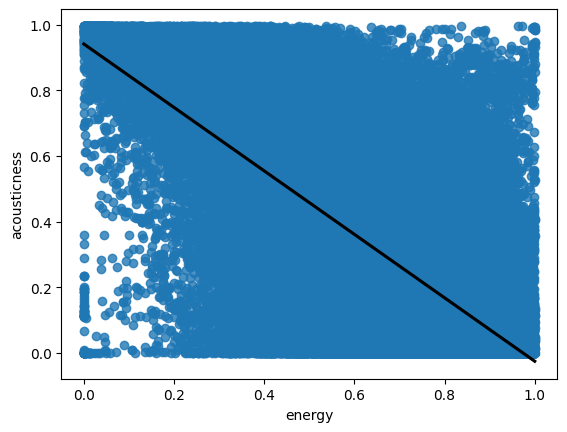

In [ ]:
#Analysis 3: Linear Regression: Acousticness vs Energy:
#Duplicates were dropped

sns.regplot(df, x="energy", y="acousticness", line_kws={'color': 'black'})
result = stats.linregress(df['energy'], df['acousticness'])
print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R:", result.rvalue)
print("P:", result.pvalue)

In [ ]:
# Analysis 4: K-Means Clustering

df = df[[
    'explicit', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo',
]]

# Encode Explicit Column:
df_binary = df[['explicit']].copy()
df_binary['explicit'] = [1 if x else 0 for x in df['explicit']]

# Separate the numeric columns
df_numeric = df[[
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo'
]]

# Pre-Process the data:
df_preprocessed = pd.concat([
    df_numeric,
    df_binary,
], axis=1)

df_preprocessed

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,explicit
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,0
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,0
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,0
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,0
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,0
...,...,...,...,...,...,...,...,...,...,...
113995,0.172,0.2350,-16.393,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,0
113996,0.174,0.1170,-18.318,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,0
113997,0.629,0.3290,-10.895,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,0
113998,0.587,0.5060,-10.889,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,0


In [ ]:
# Normalize Values:

df_preprocessed_norm = pd.concat([
    (df_numeric - df_numeric.mean())/df_numeric.std(),
    df_binary,
], axis=1)

df_preprocessed_norm

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,explicit
0,0.629236,-0.717144,0.300824,0.551841,-0.850189,-0.504109,0.758732,0.929311,-1.141849,0
1,-0.845904,-1.889966,-1.784731,-0.078995,1.831736,-0.504094,-0.591213,-0.798677,-1.489701,0
2,-0.742184,-1.122662,-0.293288,-0.273825,-0.315488,-0.504112,-0.507170,-1.365673,-1.528296,0
3,-1.733293,-2.312977,-2.039237,-0.457307,1.774597,-0.503884,-0.428379,-1.276960,1.987849,0
4,0.295024,-0.788706,-0.282750,-0.303145,0.463407,-0.504112,-0.686287,-1.184389,-0.073343,0
...,...,...,...,...,...,...,...,...,...,...
113995,-2.274946,-1.615645,-1.617314,-0.401506,0.977658,2.493731,-0.668428,-1.697771,0.128336,0
113996,-2.263422,-2.084773,-2.000067,-0.421367,2.042249,2.648792,-0.570202,-1.693528,-1.231181,0
113997,0.358409,-1.241932,-0.524133,-0.403397,1.660319,-0.504112,-0.681035,1.037310,0.341257,0
113998,0.116394,-0.538239,-0.522940,-0.519728,0.198763,-0.504112,0.296494,-0.235538,0.460744,0


In [ ]:
kmeans = KMeans(n_clusters=9, n_init='auto')
df_preprocessed['cluster'] = kmeans.fit_predict(df_preprocessed_norm)
df_preprocessed.groupby('cluster').mean().T

cluster,0,1,2,3,4,5,6,7,8
danceability,0.530549,0.670655,0.347784,0.573955,0.472004,0.470193,0.586176,0.522175,0.716733
energy,0.738668,0.507735,0.169670,0.670453,0.815388,0.313206,0.744782,0.758014,0.768906
loudness,-6.119909,-9.221327,-21.373121,-11.163560,-5.236839,-11.710334,-8.409667,-6.984827,-5.797511
speechiness,0.067194,0.081390,0.050886,0.836033,0.103635,0.044713,0.070921,0.085794,0.092800
acousticness,0.102983,0.588553,0.863385,0.732562,0.111268,0.747609,0.104530,0.281898,0.137521
instrumentalness,0.028417,0.034802,0.827048,0.009980,0.036198,0.031206,0.797010,0.068894,0.021262
liveness,0.177058,0.164539,0.161280,0.652586,0.196743,0.159251,0.170111,0.753127,0.167646
valence,0.316666,0.657978,0.185566,0.442053,0.477254,0.298959,0.332750,0.509049,0.725386
tempo,109.941132,117.154248,103.203736,101.238308,164.595194,112.773173,126.815542,123.602399,116.373098
explicit,0.109307,0.075472,0.002445,0.560550,0.110468,0.021264,0.036178,0.057371,0.126732


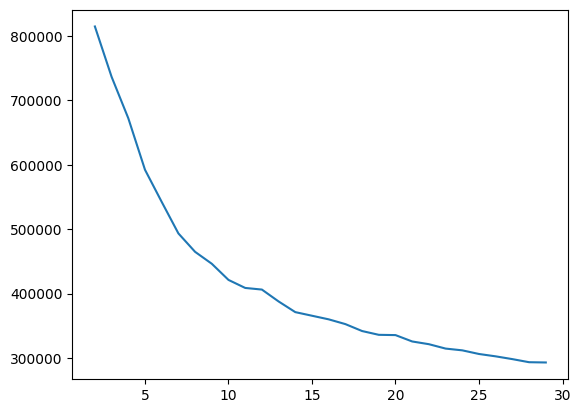

In [ ]:
# Elbow Method for the number of clusters used:

inertias = []

for k in range(2, 30):
  kmeans = KMeans(n_clusters=k, n_init='auto')
  kmeans.fit(df_preprocessed_norm)
  inertias.append(kmeans.inertia_)

plt.plot(range(2, 30), inertias)

In [ ]:
# Analysis 5: Explicit vs Non-Explicit: Popularity Comparison T-Test:
#Duplicates were dropped
exp = (df[df['explicit'] == True]['popularity'])
non_exp = (df[df['explicit'] == False]['popularity'])

result = stats.ttest_ind(exp, non_exp)
print("Explicit mean:", exp.mean())
print("Non-Explicit mean:", non_exp.mean())
print("T-statistic:", result.statistic)
print("P-value:", result.pvalue)
print("df:", result.df)

Explicit mean: 36.88564382139148
Non-Explicit mean: 32.852576917450875
T-statistic: 16.470124488546315
P-value: 7.391205139975994e-61
df: 89738.0


Slope: 15.439795175043054
Intercept: -18.29490261094318
R: 0.7587736370436359
P: 0.0


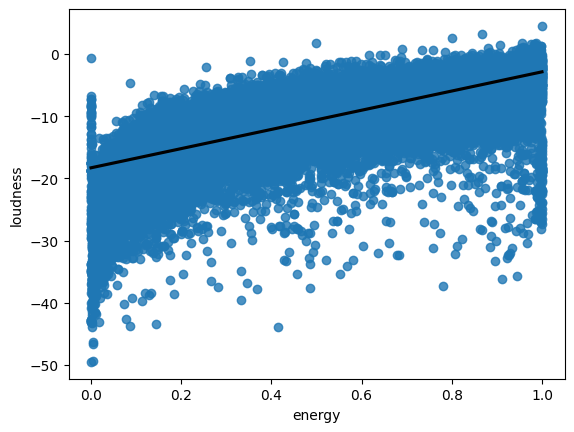

In [ ]:
#Analysis 6: Linear Regression: Loudness vs Energy:
#Duplicates were dropped

sns.regplot(df, x="energy", y="loudness", line_kws={'color': 'black'})
result = stats.linregress(df['energy'], df['loudness'])
print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R:", result.rvalue)
print("P:", result.pvalue)

In [ ]:
# just to refresh the data

df = pd.read_csv("https://raw.githubusercontent.com/HaiderrX/Spotify-Streaming-Analysis/refs/heads/main/train.csv")
df = df.dropna()
df = df.drop(columns=['Unnamed: 0'])
cols_to_convert = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']
df = df.astype({col: 'string' for col in cols_to_convert})
df.head(2)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


In [ ]:
df = df.drop_duplicates('track_id')

In [ ]:
df[df.duplicated()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
